**German Credit Dataset**

# 04 - Results Analysis

**Objectives**
- Load and combine results from the classic and fairness-aware pipelines into a single dataset (`results`)
- Parse configuration identifiers into meaningful columns for filtering and comparison
- Create unique, human-readable model IDs
- Visualize performance vs fairness trade-offs across models and mitigation strategies
- Export the cleaned and enriched results dataset for reporting

In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
from pathlib import Path
import warnings
import itertools

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import re
import warnings

In [188]:

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data

In [189]:
classic_path  = Path("../data/results/classic_models_results.csv")
fairness_path = Path("../data/results/fairness_models_results.csv")

df_classic = pd.read_csv(classic_path)
df_fairness = pd.read_csv(fairness_path)

In [190]:
df_classic

,config_id,n_splits,mean_Accuracy,mean_Precision,mean_Recall,mean_F1-Score,mean_Demographic Parity Diff.,mean_Equal Opportunity Diff.,mean_Predictive Parity Diff.,mean_Average Predictive Value Diff.,mean_Average Odds Diff.,std_Accuracy,std_Precision,std_Recall,std_F1-Score,std_Demographic Parity Diff.,std_Equal Opportunity Diff.,std_Predictive Parity Diff.,std_Average Predictive Value Diff.,std_Average Odds Diff.
0,logistic_regression|none|none|pre=none|tune=no...,3,0.745989,0.782240,0.882855,0.829453,-0.042414,-0.017142,-0.058308,-0.004939,-0.016848,0.021912,0.012080,0.023654,0.015815,0.035121,0.021764,0.035213,0.042636,0.020327
1,logistic_regression|none|none|pre=none|tune=no...,3,0.743992,0.767838,0.910030,0.832691,-0.081518,-0.048203,-0.049250,-0.018897,-0.066357,0.006670,0.014953,0.018434,0.000973,0.043226,0.056149,0.059512,0.057475,0.069832
2,logistic_regression|none|none|pre=none|tune=no...,3,0.733997,0.864449,0.735697,0.794617,0.011824,0.080554,-0.021087,0.072671,0.031801,0.006393,0.011441,0.023906,0.009371,0.017343,0.072802,0.017287,0.080006,0.007806
3,logistic_regression|none|none|pre=none|tune=ra...,3,0.742986,0.772448,0.897130,0.830133,-0.004269,0.020203,-0.063014,0.026515,0.017784,0.021962,0.013970,0.014985,0.014457,0.034827,0.055829,0.061277,0.084002,0.011771
4,logistic_regression|none|none|pre=none|tune=ra...,3,0.735981,0.761506,0.907138,0.827908,-0.020911,0.013448,-0.053433,0.041742,-0.008973,0.017118,0.013741,0.013156,0.010647,0.059911,0.064354,0.070153,0.058277,0.073109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,gradient_boosting|standardization|label|pre=di...,3,0.744028,0.788953,0.865754,0.825537,-0.060539,-0.021829,-0.041565,0.015318,-0.047267,0.026794,0.012949,0.027568,0.019547,0.060703,0.053668,0.069285,0.026555,0.068072
320,gradient_boosting|standardization|label|pre=di...,3,0.738010,0.863353,0.749991,0.795229,0.003280,0.024410,-0.067321,0.007040,0.041644,0.065198,0.039643,0.146029,0.071577,0.031830,0.037543,0.076706,0.028621,0.015354
321,gradient_boosting|standardization|label|pre=di...,3,0.758010,0.790812,0.894355,0.838184,-0.026366,0.021196,-0.040838,0.064293,-0.008182,0.034044,0.041576,0.045135,0.019558,0.034888,0.049350,0.045857,0.084811,0.010496
322,gradient_boosting|standardization|label|pre=di...,3,0.745002,0.769281,0.911510,0.833272,-0.052373,0.011726,-0.025896,0.076175,-0.051884,0.013684,0.027161,0.050855,0.010355,0.097082,0.079167,0.076660,0.046524,0.125841


In [191]:
df_fairness

,config_id,n_splits,mean_Accuracy,mean_Precision,mean_Recall,mean_F1-Score,mean_Demographic Parity Diff.,mean_Equal Opportunity Diff.,mean_Predictive Parity Diff.,mean_Average Predictive Value Diff.,...,std_Equal Opportunity Diff.,std_Predictive Parity Diff.,std_Average Predictive Value Diff.,std_Average Odds Diff.,eta,model_name,adversary_loss_weight,num_epochs,classifier_num_hidden_units,debias
0,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.736991,0.791459,0.848563,0.818799,-0.111312,-0.071883,-0.035915,0.001016,...,0.089460,0.075223,0.033293,0.128607,0.0,prejudice_remover,NaN,NaN,NaN,NaN
1,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.735990,0.788137,0.852848,0.819024,-0.098131,-0.064394,-0.044202,-0.003674,...,0.077178,0.063662,0.038035,0.108365,1.0,prejudice_remover,NaN,NaN,NaN,NaN
2,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.726987,0.776029,0.858571,0.814993,-0.057595,-0.031001,-0.056312,0.001368,...,0.067516,0.059026,0.048685,0.103240,5.0,prejudice_remover,NaN,NaN,NaN,NaN
3,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.730985,0.776223,0.865706,0.818321,-0.033033,-0.004744,-0.057243,0.012766,...,0.041085,0.066824,0.082680,0.089794,10.0,prejudice_remover,NaN,NaN,NaN,NaN
4,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.729987,0.774390,0.867136,0.818010,-0.014761,-0.007100,-0.076398,-0.020042,...,0.052521,0.066276,0.096653,0.108993,25.0,prejudice_remover,NaN,NaN,NaN,NaN
5,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.730991,0.775425,0.867142,0.818586,0.009760,0.026526,-0.070790,0.012624,...,0.043807,0.067892,0.074908,0.119668,50.0,prejudice_remover,NaN,NaN,NaN,NaN
6,AIF360|model=prejudice_remover|encoder=ordinal...,3,0.729990,0.774486,0.867142,0.818044,0.008335,0.026526,-0.069481,0.015107,...,0.043807,0.070074,0.075261,0.122475,100.0,prejudice_remover,NaN,NaN,NaN,NaN
7,AIF360|model=adversarial_debiasing|encoder=ord...,3,0.646934,0.808272,0.652654,0.717019,-0.591566,-0.626111,0.081496,-0.023316,...,0.201318,0.087639,0.028029,0.093795,NaN,adversarial_debiasing,0.01,50.0,64.0,True
8,AIF360|model=adversarial_debiasing|encoder=ord...,3,0.614072,0.765285,0.688951,0.693422,-0.394170,-0.422366,-0.033947,-0.031649,...,0.381792,0.166740,0.038533,0.355820,NaN,adversarial_debiasing,0.01,50.0,128.0,True
9,AIF360|model=adversarial_debiasing|encoder=ord...,3,0.666990,0.810604,0.705770,0.739099,-0.407855,-0.431125,-0.268588,-0.172414,...,0.341274,0.508280,0.305037,0.216234,NaN,adversarial_debiasing,0.01,50.0,200.0,True


## 2. Setup: Concatenate Results and Formart Columns

### 2.1. Cocatenate Results

In [192]:
df_classic["source"] = "classic"
df_fairness["source"] = "fairness"

results = pd.concat([df_classic, df_fairness], ignore_index=True)

In [193]:
print("Combined results shape:", results.shape)

Combined results shape: (358, 27)


In [194]:
display(results.head(10))

,config_id,n_splits,mean_Accuracy,mean_Precision,mean_Recall,mean_F1-Score,mean_Demographic Parity Diff.,mean_Equal Opportunity Diff.,mean_Predictive Parity Diff.,mean_Average Predictive Value Diff.,...,std_Predictive Parity Diff.,std_Average Predictive Value Diff.,std_Average Odds Diff.,source,eta,model_name,adversary_loss_weight,num_epochs,classifier_num_hidden_units,debias
0,logistic_regression|none|none|pre=none|tune=no...,3,0.745989,0.782240,0.882855,0.829453,-0.042414,-0.017142,-0.058308,-0.004939,...,0.035213,0.042636,0.020327,classic,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression|none|none|pre=none|tune=no...,3,0.743992,0.767838,0.910030,0.832691,-0.081518,-0.048203,-0.049250,-0.018897,...,0.059512,0.057475,0.069832,classic,NaN,NaN,NaN,NaN,NaN,NaN
2,logistic_regression|none|none|pre=none|tune=no...,3,0.733997,0.864449,0.735697,0.794617,0.011824,0.080554,-0.021087,0.072671,...,0.017287,0.080006,0.007806,classic,NaN,NaN,NaN,NaN,NaN,NaN
3,logistic_regression|none|none|pre=none|tune=ra...,3,0.742986,0.772448,0.897130,0.830133,-0.004269,0.020203,-0.063014,0.026515,...,0.061277,0.084002,0.011771,classic,NaN,NaN,NaN,NaN,NaN,NaN
4,logistic_regression|none|none|pre=none|tune=ra...,3,0.735981,0.761506,0.907138,0.827908,-0.020911,0.013448,-0.053433,0.041742,...,0.070153,0.058277,0.073109,classic,NaN,NaN,NaN,NaN,NaN,NaN
5,logistic_regression|none|none|pre=none|tune=ra...,3,0.732978,0.857679,0.742777,0.795173,-0.026469,0.031478,-0.023298,0.053437,...,0.042190,0.088532,0.026364,classic,NaN,NaN,NaN,NaN,NaN,NaN
6,random_forest|none|none|pre=none|tune=none|pos...,3,0.766006,0.788452,0.909994,0.844850,-0.033911,0.017046,-0.039005,0.053183,...,0.038880,0.104570,0.013763,classic,NaN,NaN,NaN,NaN,NaN,NaN
7,random_forest|none|none|pre=none|tune=none|pos...,3,0.745994,0.762047,0.927161,0.836423,-0.084318,-0.007386,-0.014173,0.095528,...,0.068260,0.062794,0.118989,classic,NaN,NaN,NaN,NaN,NaN,NaN
8,random_forest|none|none|pre=none|tune=none|pos...,3,0.766980,0.850875,0.809924,0.829151,-0.029410,0.000211,-0.057900,0.009892,...,0.036273,0.058531,0.012778,classic,NaN,NaN,NaN,NaN,NaN,NaN
9,random_forest|none|none|pre=none|tune=random|p...,3,0.757003,0.803819,0.868597,0.833265,-0.029387,0.011981,-0.044071,0.043823,...,0.030455,0.054071,0.024403,classic,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2. Format Columns

In [195]:
MODEL_PREFIX = {
    "logistic_regression": "LG",
    "random_forest": "RF",
    "gradient_boosting": "GB",
    "prejudice_remover": "PR",
    "adversarial_debiasing": "AD",
}

# Normalize inputs once (avoid repeated astype/strip/lower in multiple places)
src = results["source"].astype(str).str.strip().str.lower()
cfg = results.get("config_id", "").astype(str)

# -----------------------------------------------------------------------------
# 1) Build a single canonical "model" name without creating helper columns.
#    - classic: model is the first token in "model|scaler|encoder|pre=...|tune=...|post=..."
#              If the string is not in the expected 6-part format, fall back to the raw config_id.
#    - fairness: model is extracted from "model=..." if present; otherwise fall back to config_id.
# -----------------------------------------------------------------------------
classic_expected_format = cfg.str.count(r"\|") >= 5  # at least 6 tokens => 5 pipes
model_classic = cfg.str.split("|").str[0].where(classic_expected_format, cfg)
model_fair = cfg.str.extract(r"model=([^|]+)", expand=False).fillna(cfg)

results["model"] = model_classic.where(src.eq("classic"), model_fair)

# -----------------------------------------------------------------------------
# 2) Parse classic-only knobs (scaler/encoder/bias/tuning)
#    For fairness-aware rows, force scaler/encoder to the known constants.
# -----------------------------------------------------------------------------
is_classic = src.eq("classic") & classic_expected_format
is_fairness = src.eq("fairness")

spl = cfg.str.split("|", expand=True)

# Classic values (only when format matches)
results["scaler"] = spl[1].where(is_classic)
results["encoder"] = spl[2].where(is_classic)

# Fairness constants (always)
results.loc[is_fairness, "scaler"] = "standardization"
results.loc[is_fairness, "encoder"] = "label"

# Remove fixed prefixes pre=/tune=/post= and use a stable default ("none")
results["bias_pre"] = (
    spl[3].str.replace(r"^pre=", "", regex=True).where(is_classic).fillna("none")
)
results["tuning"] = (
    spl[4].str.replace(r"^tune=", "", regex=True).where(is_classic).fillna("none")
)
results["bias_post"] = (
    spl[5].str.replace(r"^post=", "", regex=True).where(is_classic).fillna("none")
)

# -----------------------------------------------------------------------------
# 3) Create a compact model_id like "LG001", "RF002", etc.
#    Ranking is per-prefix and uses row order as the tie-breaker (stable within the current results).
# -----------------------------------------------------------------------------
prefix = results["model"].map(MODEL_PREFIX).fillna("MD")
rank = prefix.groupby(prefix).cumcount() + 1
results["model_id"] = prefix + rank.astype(str).str.zfill(3)

# -----------------------------------------------------------------------------
# 4) Drop columns you don't want and reorder: identifiers/params first, then metrics.
# -----------------------------------------------------------------------------
to_drop = [c for c in [
    "model_prefix", "config_id", "model_name", "config_raw", "model_name_parsed",
    "fair_model", "fair_encoder", "fair_scaler", "fair_params_raw", "model_family",
] if c in results.columns]
results = results.drop(columns=to_drop)

front = [
    "model_id", "model", "source", "scaler", "encoder", "bias_pre", "tuning", "bias_post",
    "n_splits", "eta", "adversary_loss_weight", "num_epochs",
    "classifier_num_hidden_units", "debias",
]

# Keep all metric columns together (e.g., mean_* and std_*) so comparisons are easier
metrics = [c for c in results.columns if c.startswith("mean_") or c.startswith("std_")]
rest = [c for c in results.columns if c not in front + metrics]

results = results[front + metrics + rest]

In [196]:
results

,model_id,model,source,scaler,encoder,bias_pre,tuning,bias_post,n_splits,eta,...,mean_Average Odds Diff.,std_Accuracy,std_Precision,std_Recall,std_F1-Score,std_Demographic Parity Diff.,std_Equal Opportunity Diff.,std_Predictive Parity Diff.,std_Average Predictive Value Diff.,std_Average Odds Diff.
0,LG001,logistic_regression,classic,none,none,none,none,none,3,NaN,...,-0.016848,0.021912,0.012080,0.023654,0.015815,0.035121,0.021764,0.035213,0.042636,0.020327
1,LG002,logistic_regression,classic,none,none,none,none,calibrate_equalized_odds,3,NaN,...,-0.066357,0.006670,0.014953,0.018434,0.000973,0.043226,0.056149,0.059512,0.057475,0.069832
2,LG003,logistic_regression,classic,none,none,none,none,reject_option_classification,3,NaN,...,0.031801,0.006393,0.011441,0.023906,0.009371,0.017343,0.072802,0.017287,0.080006,0.007806
3,LG004,logistic_regression,classic,none,none,none,random,none,3,NaN,...,0.017784,0.021962,0.013970,0.014985,0.014457,0.034827,0.055829,0.061277,0.084002,0.011771
4,LG005,logistic_regression,classic,none,none,none,random,calibrate_equalized_odds,3,NaN,...,-0.008973,0.017118,0.013741,0.013156,0.010647,0.059911,0.064354,0.070153,0.058277,0.073109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,AD023,adversarial_debiasing,fairness,standardization,label,none,none,none,3,NaN,...,0.000000,0.000519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031754,0.000000
354,AD024,adversarial_debiasing,fairness,standardization,label,none,none,none,3,NaN,...,0.000000,0.000519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031754,0.000000
355,AD025,adversarial_debiasing,fairness,standardization,label,none,none,none,3,NaN,...,-0.119243,0.194090,0.521586,0.354637,0.380759,0.151097,0.112711,0.566272,0.317321,0.138859
356,AD026,adversarial_debiasing,fairness,standardization,label,none,none,none,3,NaN,...,0.000000,0.000519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031754,0.000000


In [197]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   model_id                             358 non-null    str    
 1   model                                358 non-null    object 
 2   source                               358 non-null    str    
 3   scaler                               358 non-null    str    
 4   encoder                              358 non-null    str    
 5   bias_pre                             358 non-null    str    
 6   tuning                               358 non-null    str    
 7   bias_post                            358 non-null    str    
 8   n_splits                             358 non-null    int64  
 9   eta                                  7 non-null      float64
 10  adversary_loss_weight                27 non-null     float64
 11  num_epochs                           27 non

## 3. Results Analysis

In [198]:
METRICS = [
    "mean_Accuracy",
    "mean_F1-Score",
    "mean_Demographic Parity Diff.",
    "mean_Equal Opportunity Diff.",
    "mean_Predictive Parity Diff.",
    "mean_Average Predictive Value Diff.",
    "mean_Average Odds Diff."
]

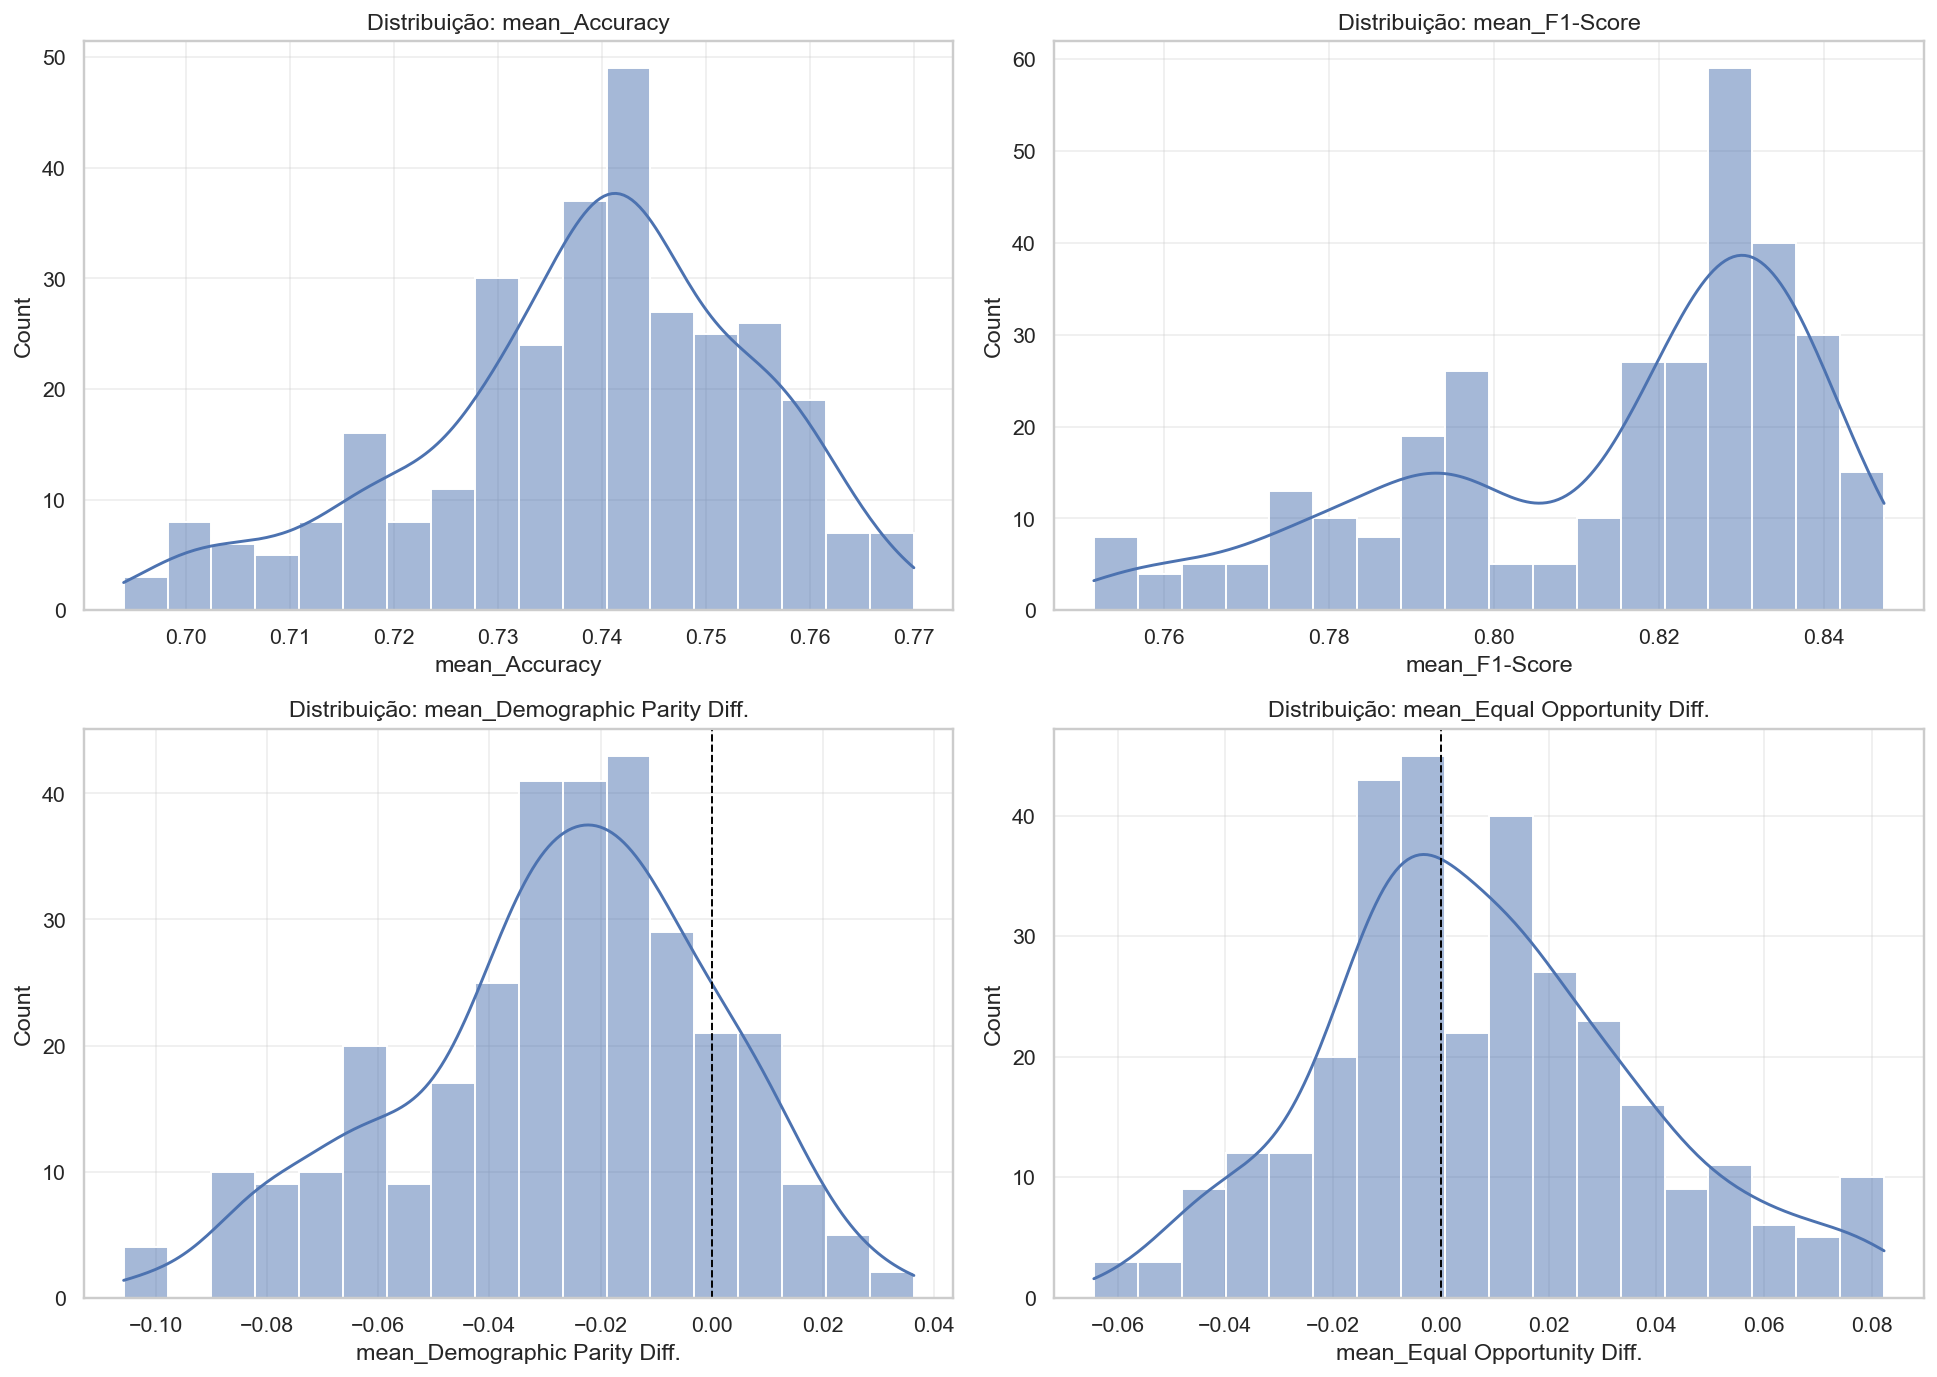

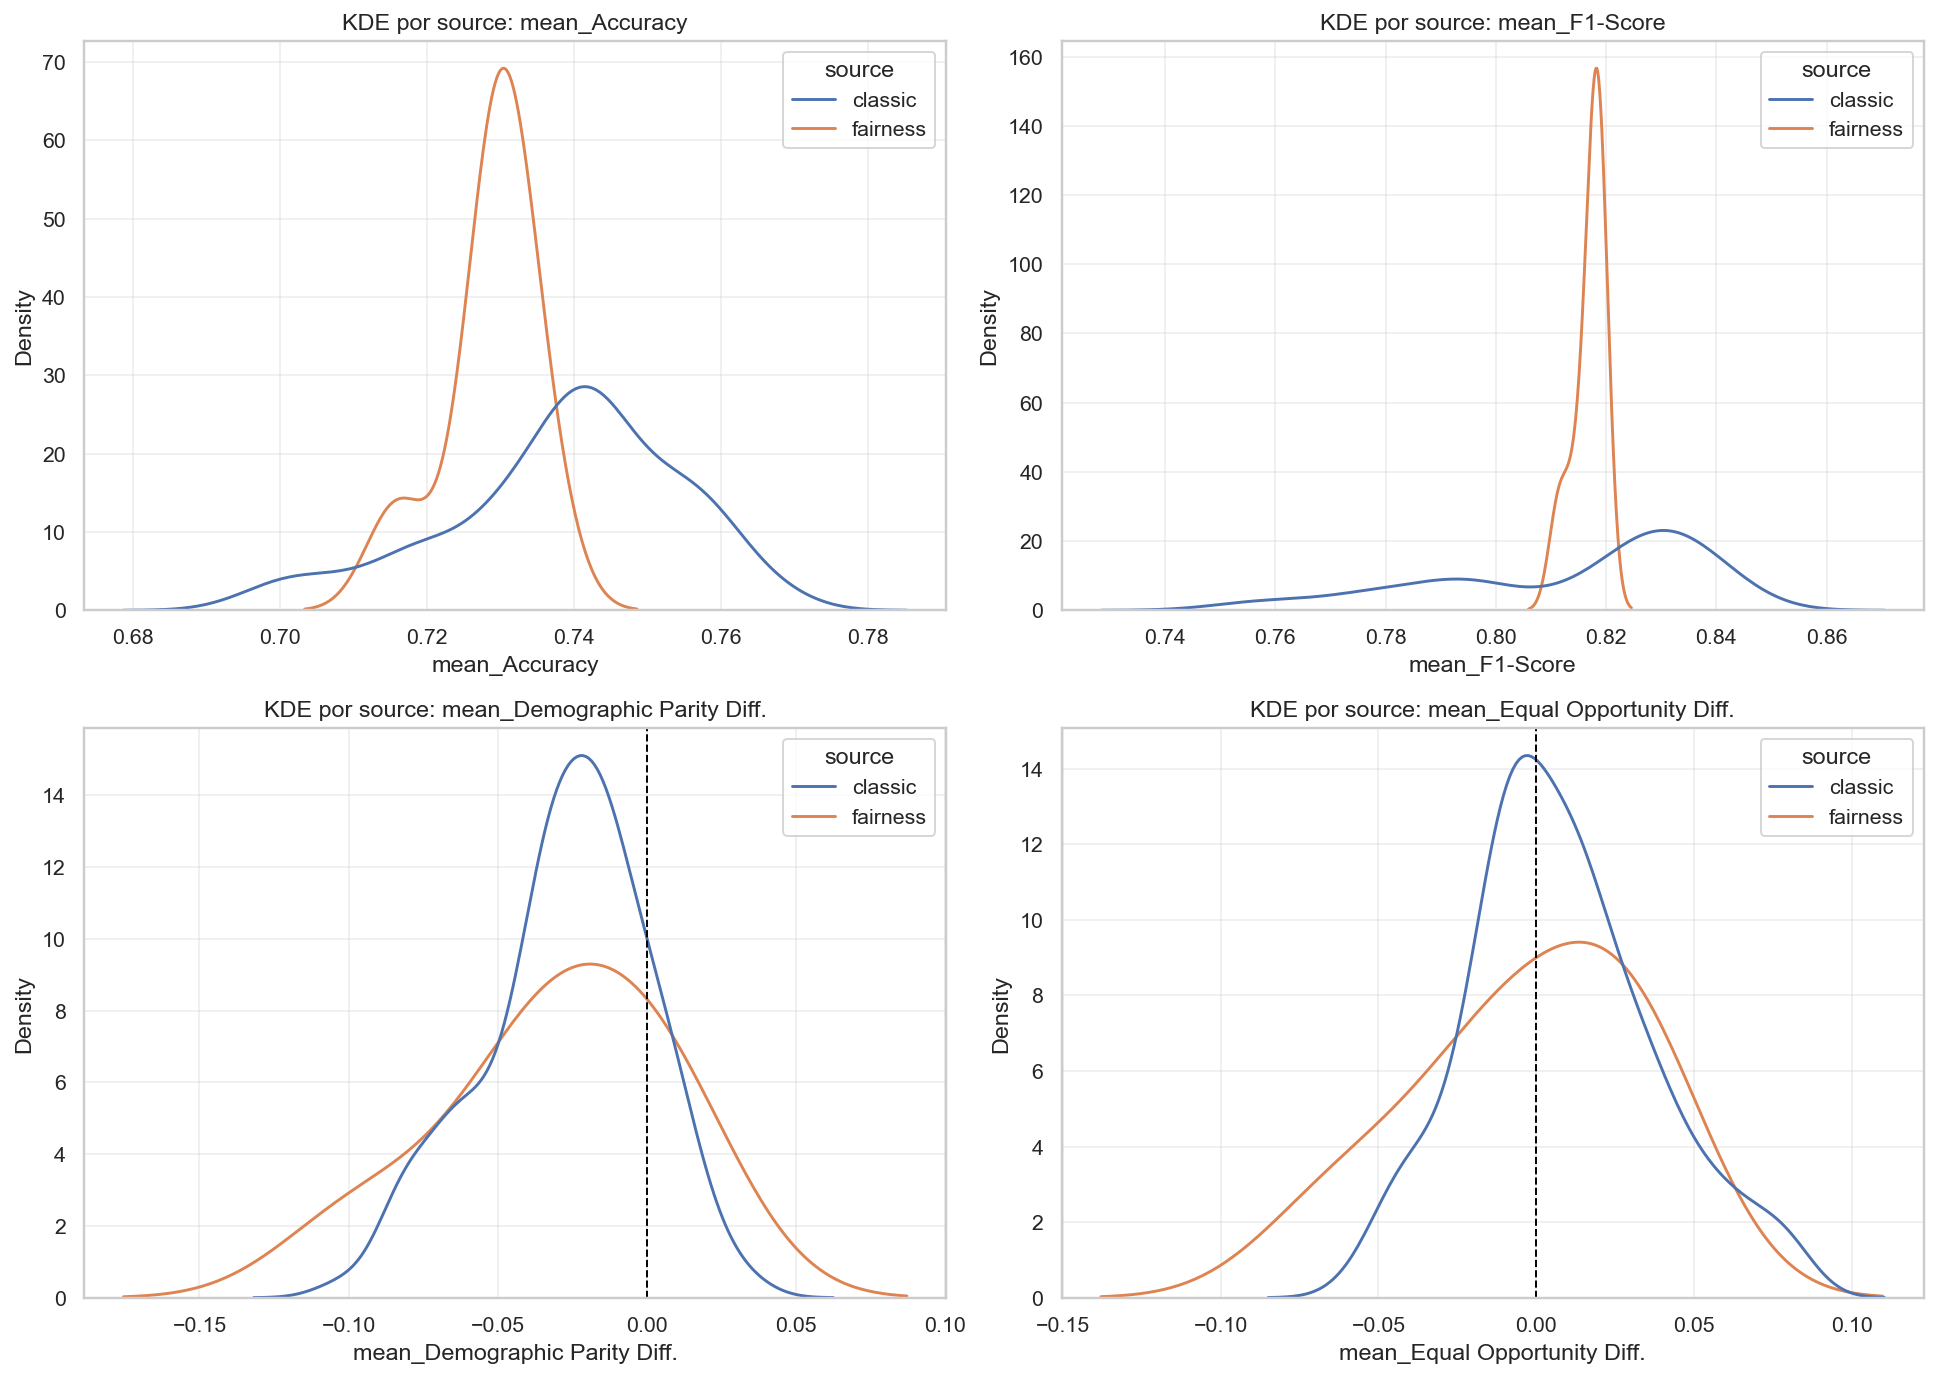

In [199]:
# Distribuição geral das métricas 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, m in zip(axes, METRICS):
    sns.histplot(data=res, x=m, kde=True, ax=ax, bins=18)
    ax.set_title(f"Distribuição: {m}")
    # Linhas guia
    if "Diff." in m:
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, m in zip(axes, METRICS):
    sns.kdeplot(data=res, x=m, hue="source", common_norm=False, ax=ax)
    ax.set_title(f"KDE por source: {m}")
    if "Diff." in m:
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Top 5 modelos por métrica

def top5_by_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    cols = ["model_id", "model", "source", "bias_pre", "bias_post", "tuning", metric]
    if "Diff." in metric:
        out = df.assign(abs_metric=df[metric].abs()).sort_values(["abs_metric", metric], ascending=[True, True]).head(5)
        return out[cols + ["abs_metric"]]
    else:
        out = df.sort_values(metric, ascending=False).head(5)
        return out[cols]

for m in METRICS:
    print(f"\nTop 5 por: {m}")
    display(top5_by_metric(res, m))


Top 5 por: mean_Accuracy


,model_id,model,source,bias_pre,bias_post,tuning,mean_Accuracy
178,RF061,random_forest,classic,none,none,none,0.770004
110,RF037,random_forest,classic,none,none,none,0.770004
77,RF027,random_forest,classic,none,reject_option_classification,none,0.767978
8,RF003,random_forest,classic,none,reject_option_classification,none,0.766980
180,RF063,random_forest,classic,none,reject_option_classification,none,0.766980



Top 5 por: mean_F1-Score


,model_id,model,source,bias_pre,bias_post,tuning,mean_F1-Score
110,RF037,random_forest,classic,none,none,none,0.847293
178,RF061,random_forest,classic,none,none,none,0.847293
6,RF001,random_forest,classic,none,none,none,0.844850
75,RF025,random_forest,classic,none,none,none,0.844850
15,GB004,gradient_boosting,classic,none,none,random,0.844510



Top 5 por: mean_Demographic Parity Diff.


...

,model_id,model,source,bias_pre,bias_post,tuning,mean_Predictive Parity Diff.,abs_metric
142,LG051,logistic_regression,classic,none,reject_option_classification,none,-0.004138,0.004138
210,LG076,logistic_regression,classic,disparate-impact-remover,none,random,-0.007570,0.007570
143,LG052,logistic_regression,classic,none,none,random,-0.008788,0.008788
54,LG021,logistic_regression,classic,reweighing,reject_option_classification,none,-0.008907,0.008907
160,LG058,logistic_regression,classic,reweighing,none,random,-0.009131,0.009131



Top 5 por: mean_Average Predictive Value Diff.


,model_id,model,source,bias_pre,bias_post,tuning,mean_Average Predictive Value Diff.,abs_metric
121,GB042,gradient_boosting,classic,none,reject_option_classification,random,-0.000114,0.000114
61,RF022,random_forest,classic,reweighing,none,random,-0.000164,0.000164
102,GB035,gradient_boosting,classic,reweighing,calibrate_equalized_odds,random,0.000414,0.000414
293,LG103,logistic_regression,classic,disparate-impact-remover,none,none,0.000502,0.000502
62,RF023,random_forest,classic,reweighing,calibrate_equalized_odds,random,-0.000592,0.000592



Top 5 por: mean_Average Odds Diff.


,model_id,model,source,bias_pre,bias_post,tuning,mean_Average Odds Diff.,abs_metric
18,LG007,logistic_regression,classic,reweighing,none,none,-0.000302,0.000302
277,LG097,logistic_regression,classic,disparate-impact-remover,none,none,-0.000325,0.000325
150,RF054,random_forest,classic,none,reject_option_classification,random,0.000414,0.000414
176,LG064,logistic_regression,classic,none,none,random,-0.000487,0.000487
126,LG047,logistic_regression,classic,reweighing,calibrate_equalized_odds,random,0.000871,0.000871


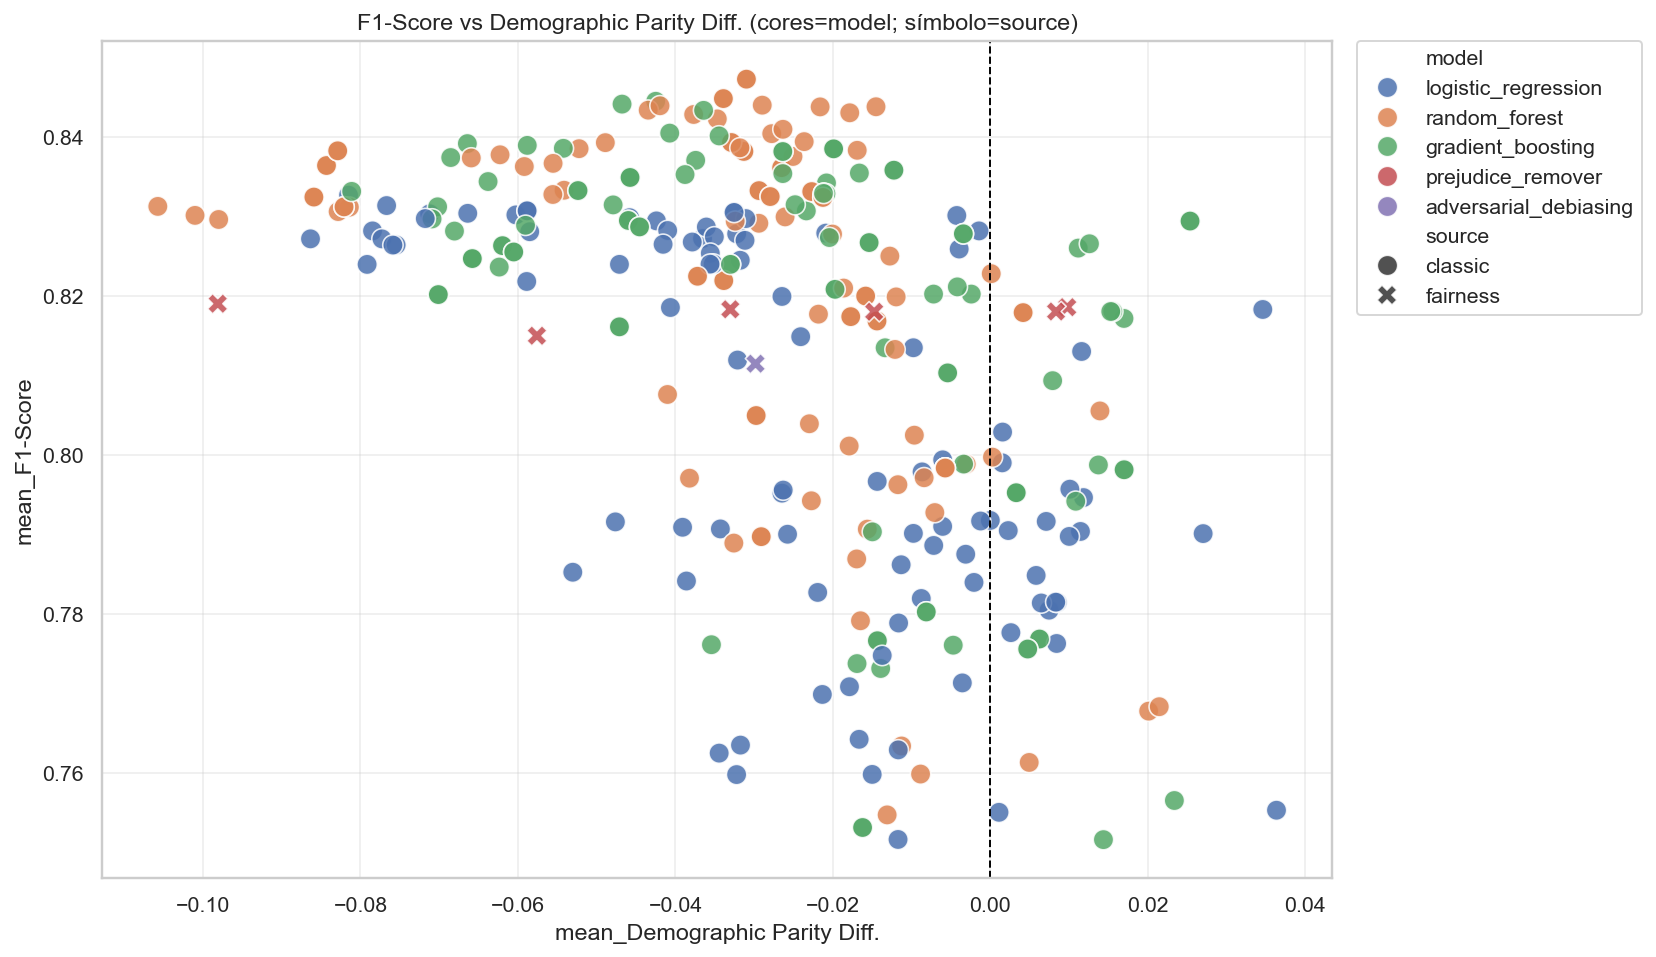

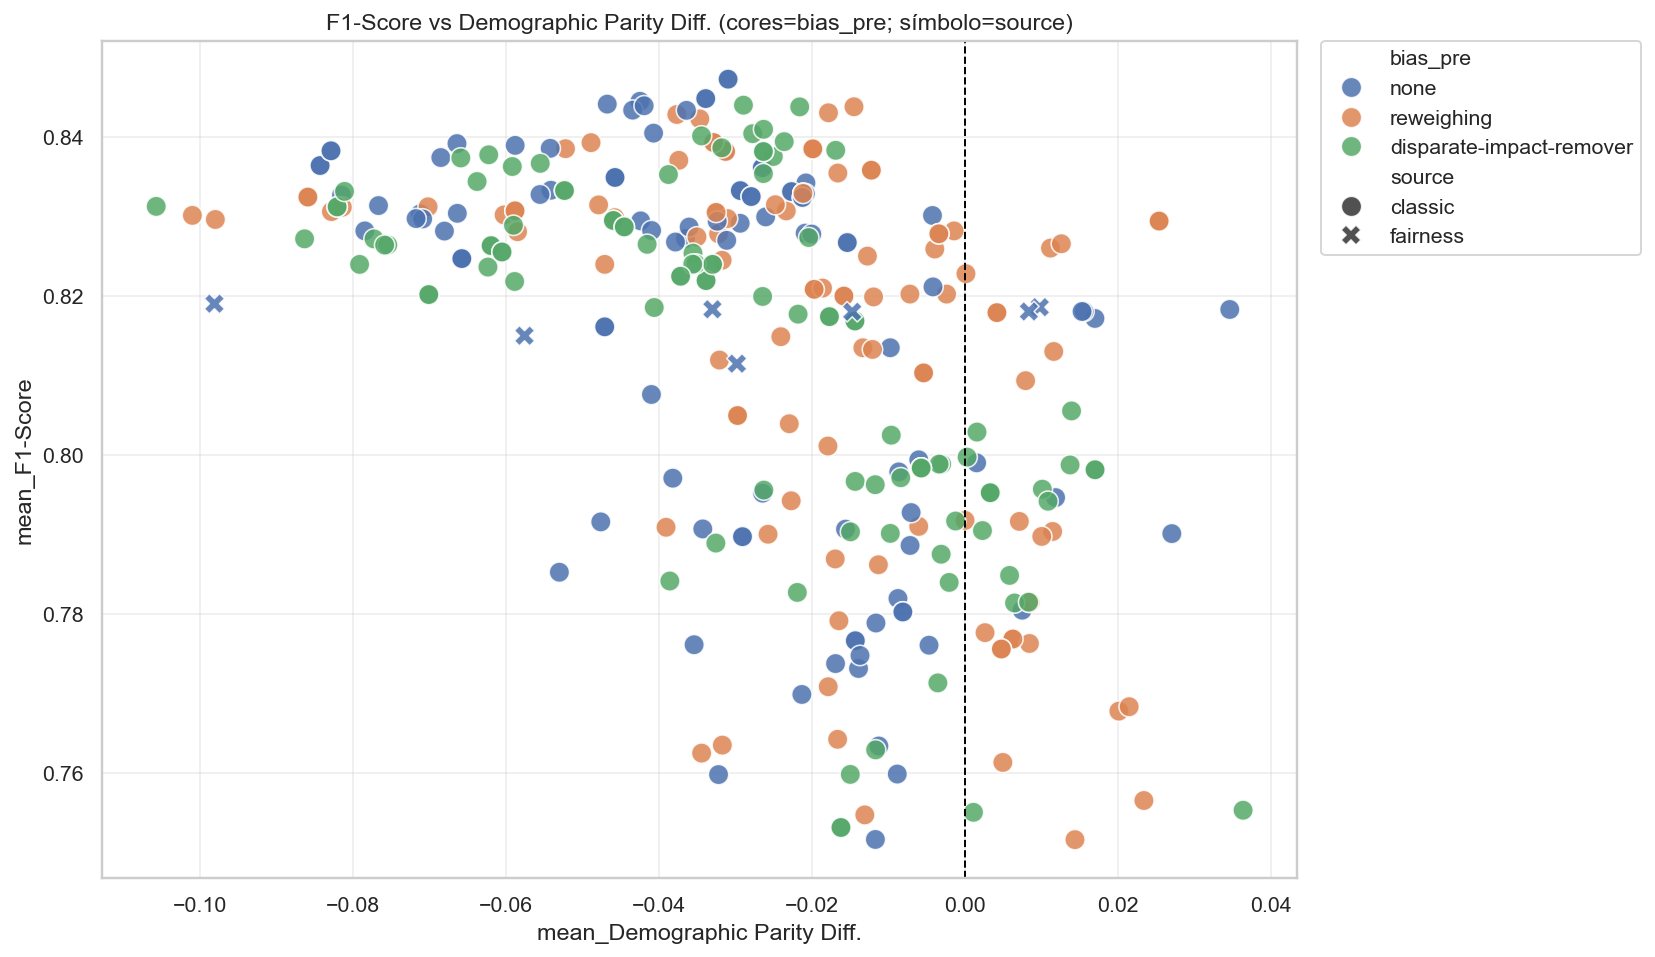

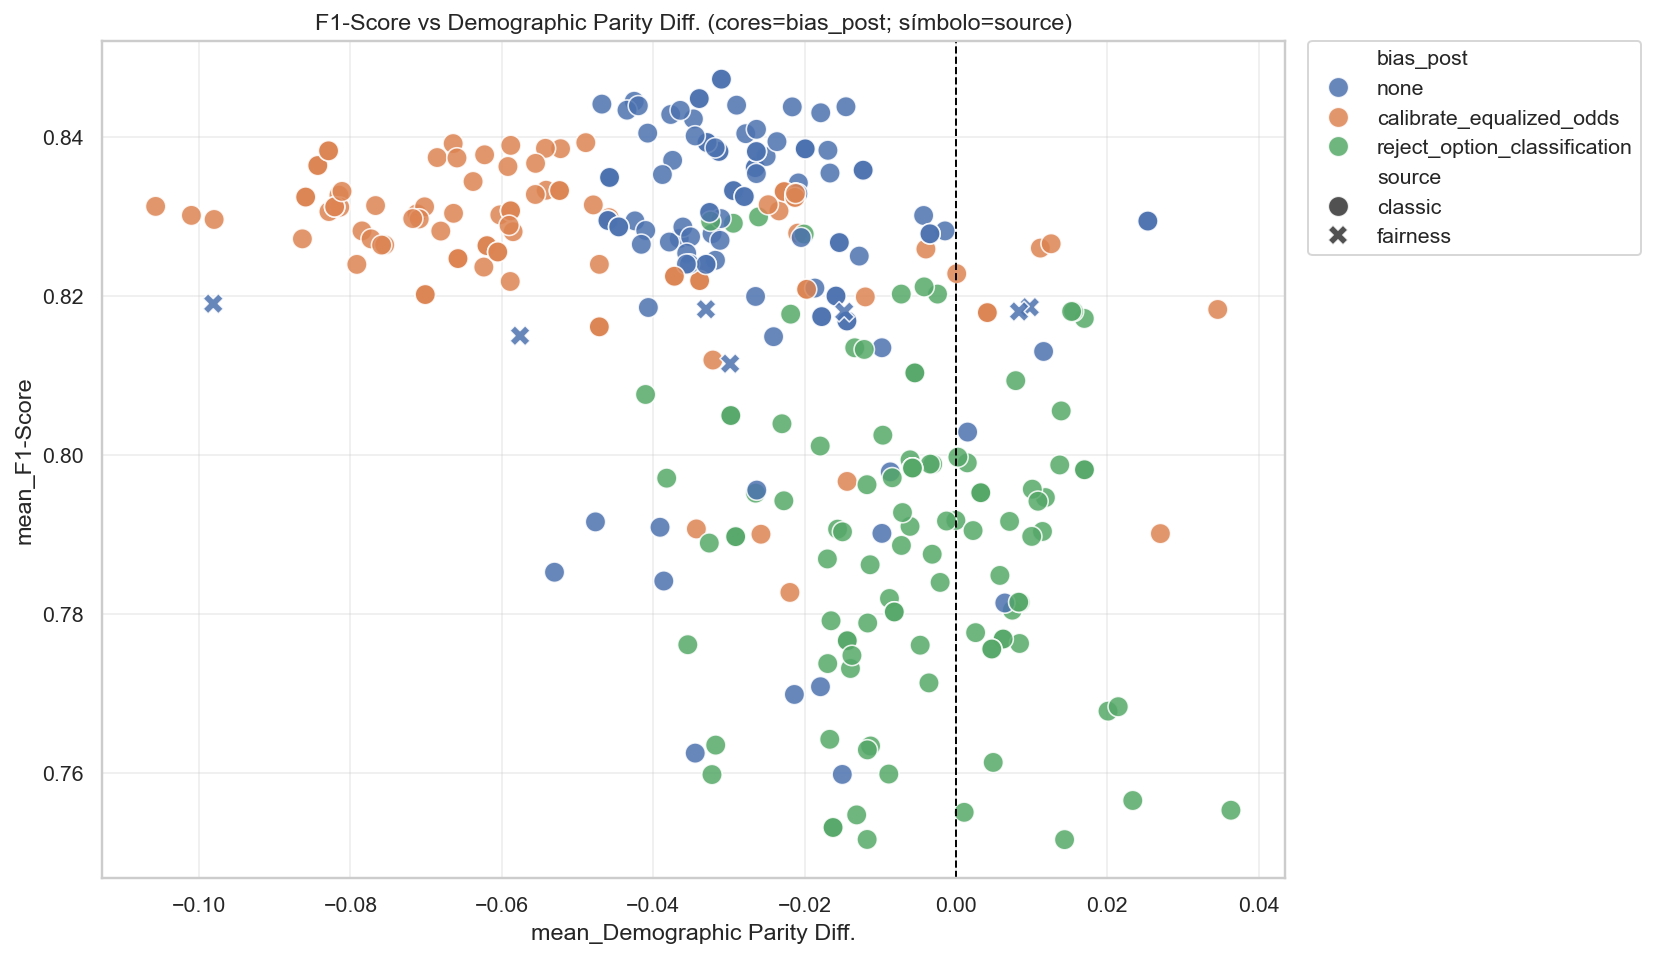

In [201]:
# ============================================================
# 3.4 Scatterplots: mean_F1-Score x mean_Demographic Parity Diff.
#     para: model, bias_pre, bias_post
#     - cores: valores da característica
#     - símbolos: source (classic vs fairness)
# ============================================================

X = "mean_Demographic Parity Diff."
Y = "mean_F1-Score"

def scatter_by_feature(df: pd.DataFrame, feature: str, title: str):
    plt.figure(figsize=(12, 7))
    ax = sns.scatterplot(
        data=df,
        x=X, y=Y,
        hue=feature,
        style="source",   # símbolos por source
        s=110,
        alpha=0.85
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

scatter_by_feature(res, "model", "F1-Score vs Demographic Parity Diff. (cores=model; símbolo=source)")
scatter_by_feature(res, "bias_pre", "F1-Score vs Demographic Parity Diff. (cores=bias_pre; símbolo=source)")
scatter_by_feature(res, "bias_post", "F1-Score vs Demographic Parity Diff. (cores=bias_post; símbolo=source)")

In [202]:
# ============================================================
# 3.5 Seleção final: score de trade-off (ajuda a escolher 5)
#     Ideia:
#       - Normaliza performance (Accuracy, F1) para [0,1] com min-max
#       - Penaliza unfairness com |diff| (DP e EO), normalizados
#       - score = w_perf*(F1_norm + Acc_norm)/2 - w_fair*(DP_abs_norm + EO_abs_norm)/2
#     Ajuste pesos conforme sua preferência.
# ============================================================

df = res.copy()

# Métricas auxiliares (preserva sinal nas colunas originais; usa abs só para penalizar)
df["abs_DP"] = df["mean_Demographic Parity Diff."].abs()
df["abs_EO"] = df["mean_Equal Opportunity Diff."].abs()

def minmax(s):
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(0.0, index=s.index)
    return (s - lo) / (hi - lo)

df["acc_norm"] = minmax(df["mean_Accuracy"])
df["f1_norm"]  = minmax(df["mean_F1-Score"])
df["dp_norm"]  = minmax(df["abs_DP"])
df["eo_norm"]  = minmax(df["abs_EO"])

W_PERF = 0.60
W_FAIR = 0.40

df["tradeoff_score"] = (
    W_PERF * (df["acc_norm"] + df["f1_norm"]) / 2
    - W_FAIR * (df["dp_norm"] + df["eo_norm"]) / 2
)

top_tradeoff = df.sort_values("tradeoff_score", ascending=False).head(5)[
    ["model_id", "model", "source", "bias_pre", "bias_post", "tuning",
     "mean_Accuracy", "mean_F1-Score", "mean_Demographic Parity Diff.", "mean_Equal Opportunity Diff.",
     "tradeoff_score"]
]

print("\nTOP 5 (trade-off score) — candidatos finais")
display(top_tradeoff)


TOP 5 (trade-off score) — candidatos finais


,model_id,model,source,bias_pre,bias_post,tuning,mean_Accuracy,mean_F1-Score,mean_Demographic Parity Diff.,mean_Equal Opportunity Diff.,tradeoff_score
230,RF079,random_forest,classic,disparate-impact-remover,none,none,0.762011,0.843806,-0.021625,-0.004438,0.506323
110,RF037,random_forest,classic,none,none,none,0.770004,0.847293,-0.030985,0.015131,0.505046
178,RF061,random_forest,classic,none,none,none,0.770004,0.847293,-0.030985,0.015131,0.505046
61,RF022,random_forest,classic,reweighing,none,random,0.756011,0.843062,-0.017864,0.002143,0.493007
164,RF058,random_forest,classic,reweighing,none,random,0.757009,0.843822,-0.014531,0.007698,0.492093


## 3. Exporting Results

In [203]:
file_out_path = '../data/results'

results.to_csv(file_out_path + '/final_results.csv', index=False)

In [246]:
(
    results[
        (results["model_id"] == "RF022") &
        (results["bias_post"] == "none")

    ]
    .assign(abs_aod=lambda df: df["mean_Demographic Parity Diff."].abs())
    .sort_values("abs_aod", ascending=True)
    [[
        "model_id",
        "model",
        "mean_Equal Opportunity Diff.",
        "mean_Demographic Parity Diff."

        
    ]]
    .head(5)
)

#reweighing	
#disparate-impact-remover

,model_id,model,mean_Equal Opportunity Diff.,mean_Demographic Parity Diff.
63,RF022,random_forest,0.002143,-0.017864
